# Import Libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, average_precision_score, matthews_corrcoef, precision_recall_curve, roc_curve
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, ClassifierMixin
import joblib

import warnings
warnings.filterwarnings('ignore')

# Get Data

In [2]:
df = pd.read_csv('data/AIML Dataset.csv')

In [3]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4069849,300,PAYMENT,19130.95,C1135641142,0.0,0.00,M1525183737,0.00,0.00,0,0
1370026,138,PAYMENT,19446.14,C991365486,0.0,0.00,M214738675,0.00,0.00,0,0
5425384,378,CASH_OUT,32570.19,C1496685450,1140.0,0.00,C2008359427,665912.73,698482.92,0,0
428441,18,CASH_OUT,13670.76,C580673202,29769.0,16098.24,C162114152,122934.80,136605.57,0,0
5092663,355,CASH_OUT,203518.96,C943201451,20920.0,0.00,C1226031753,4935459.67,5138978.63,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,113


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [8]:
list(df.columns)

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [11]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# EDA

In [12]:
round((df['isFraud'].value_counts()[1]/df.shape[0])*100, 3) # there is a class impalance

np.float64(0.129)

In [13]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

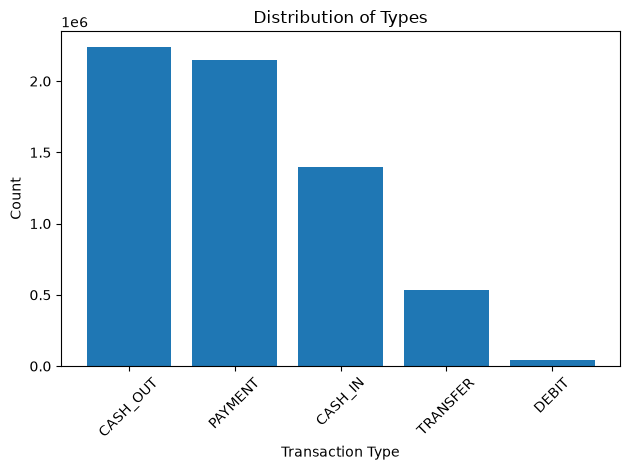

In [14]:
type_counts = df['type'].value_counts()

plt.bar(type_counts.index, type_counts.values)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Types')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [15]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

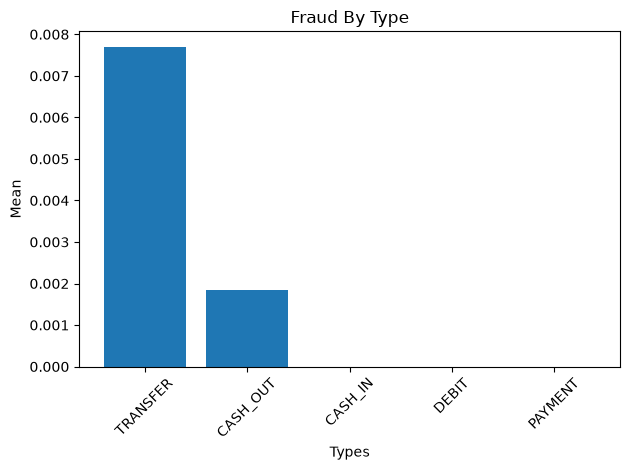

In [16]:
plt.bar(fraud_by_type.index, fraud_by_type.values)
plt.xlabel('Types')
plt.ylabel('Mean')
plt.title('Fraud By Type')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [17]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

In [18]:
df['amount'].median()

np.float64(74871.94)

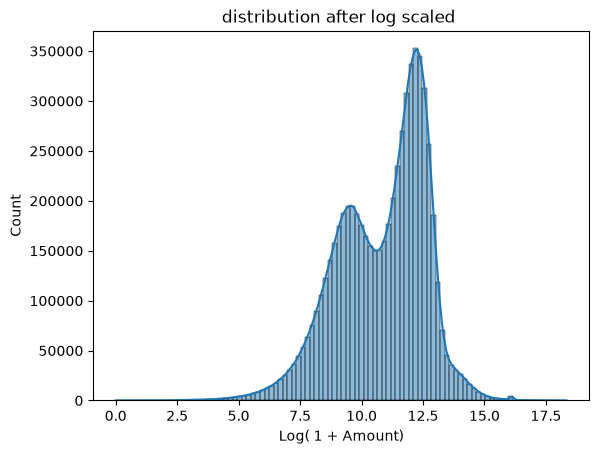

In [19]:
sns.histplot(np.log1p(df['amount']), bins = 100, kde = True)
plt.title("distribution after log scaled ")
plt.xlabel("Log( 1 + Amount)")
plt.show()

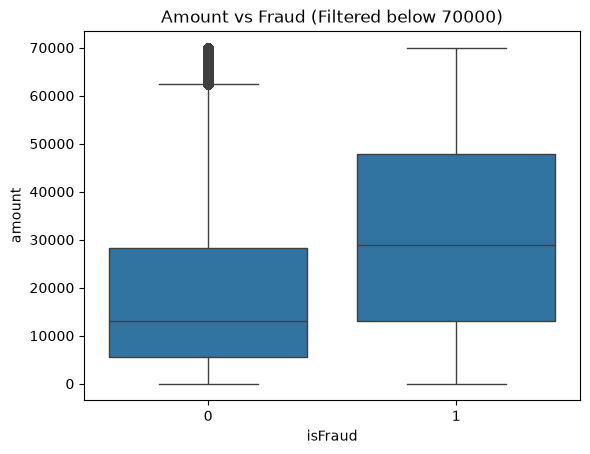

In [20]:
sns.boxplot(data = df[df['amount'] < 70000], x = 'isFraud', y = 'amount')
plt.title("Amount vs Fraud (Filtered below 70000)")
plt.show()

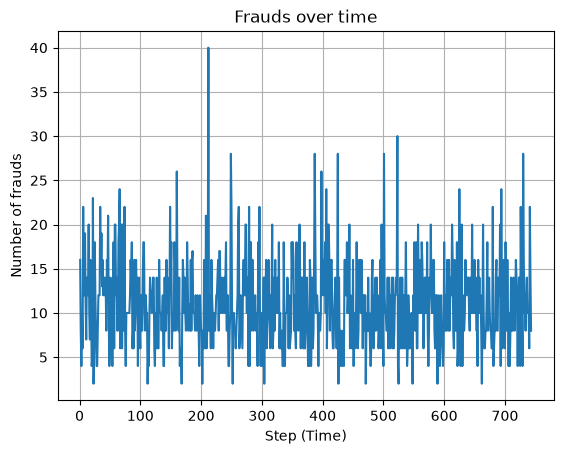

In [21]:
frauds_per_Step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()

plt.plot(frauds_per_Step.index, frauds_per_Step.values, label = "fraud per step")
plt.title("Frauds over time")
plt.xlabel("Step (Time)")
plt.ylabel("Number of frauds")
plt.grid(True)
plt.show()
# we gain that it is time independent so let's drop it

In [22]:
top_senders = df['nameOrig'].value_counts().head(10)
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [23]:
top_recievers = df['nameDest'].value_counts().head(10)
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [24]:
fraud_users = df[df['isFraud'] == 1]['nameDest'].value_counts().head(10)
fraud_users

nameDest
C410033330     2
C803116137     2
C904300960     2
C1013511446    2
C2020337583    2
C200064275     2
C185805228     2
C52390890      2
C935310781     2
C1827219533    2
Name: count, dtype: int64

In [25]:
transfer_and_cash_out_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [26]:
transfer_and_cash_out_df['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

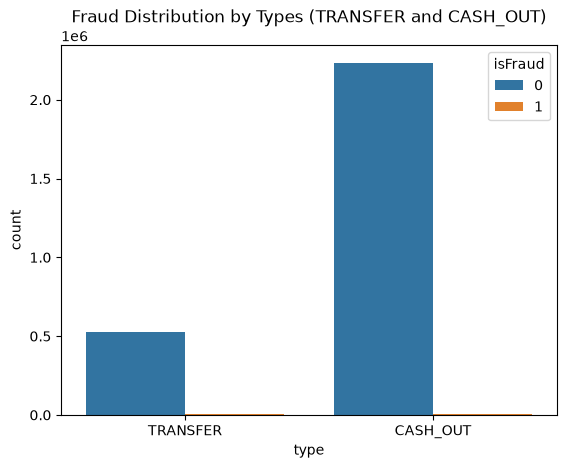

In [27]:
sns.countplot(data = transfer_and_cash_out_df, x ='type', hue = 'isFraud')
plt.title("Fraud Distribution by Types (TRANSFER and CASH_OUT)")
plt.show()

In [28]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [29]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

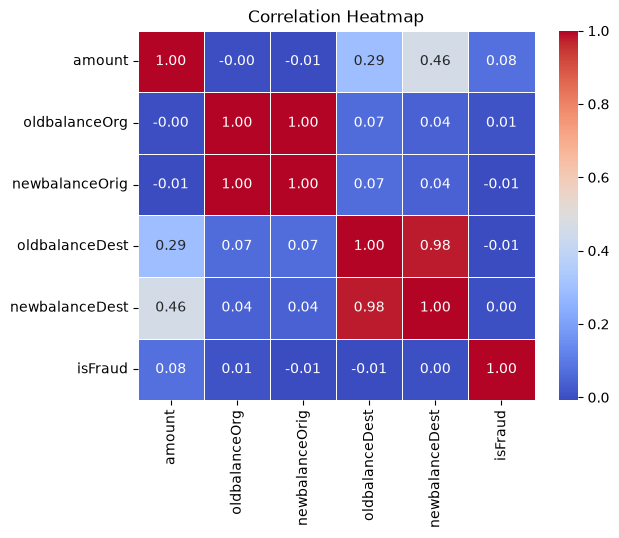

In [30]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")

In [31]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) & 
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]

In [32]:
len(zero_after_transfer)

1188074

In [33]:
zero_after_transfer.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1968539,178,CASH_OUT,281605.82,C1005519101,23694.21,0.0,C1370423976,3228810.00,3510415.82,0,0
2745938,212,CASH_OUT,85714.77,C1905825822,20817.00,0.0,C518134049,486053.74,571768.51,0,0
374182,17,CASH_OUT,177005.58,C1498736320,39285.97,0.0,C1475878908,213540.37,390545.95,0,0
5820061,401,CASH_OUT,129028.97,C140663606,21455.00,0.0,C156411687,568273.35,697302.32,0,0
1801551,162,TRANSFER,937644.96,C1235598748,34734.00,0.0,C1956948805,0.00,937644.96,0,0


# Feature Engineering

In [34]:
# Basic Balance Features
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['oldbalanceDest'] - df['newbalanceDest']

In [35]:
# Transaction Amount Features
df['amount_log'] = np.log1p(df['amount'])
df['amount_to_balance_orig'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['amount_to_balance_dest'] = df['amount'] / (df['oldbalanceDest'] + 1)

In [36]:
# User Transaction History Features
df['transaction_count_orig'] = df.groupby('nameOrig')['amount'].transform('count')
df['transaction_count_dest'] = df.groupby('nameDest')['amount'].transform('count')

In [37]:
# Average and std amount per origin account
df['avg_amount_orig'] = df.groupby('nameOrig')['amount'].transform('mean')
df['std_amount_orig'] = df.groupby('nameOrig')['amount'].transform('std')
df['avg_amount_dest'] = df.groupby('nameDest')['amount'].transform('mean')

In [38]:
# Amount relative to user's historical average
df['amount_vs_avg_orig'] = df['amount'] / (df['avg_amount_orig'] + 1)
df['amount_vs_avg_dest'] = df['amount'] / (df['avg_amount_dest'] + 1)

In [39]:
# Time-based Features
df['hour_of_day'] = df['step'] % 24
df['day_of_week'] = (df['step'] // 24) % 7
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_night'] = df['hour_of_day'].apply(lambda x: 1 if x < 6 or x > 22 else 0)

In [40]:
# Merchant Features
df['is_merchant_orig'] = df['nameOrig'].str.startswith('M').astype(int)
df['is_merchant_dest'] = df['nameDest'].str.startswith('M').astype(int)

In [41]:
# Anomaly Detection Features
df['balance_to_zero_orig'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)
df['balance_to_zero_dest'] = ((df['oldbalanceDest'] > 0) & (df['newbalanceDest'] == 0)).astype(int)

In [42]:
# Large transaction relative to user's average
df['large_transaction_orig'] = (df['amount'] > df['avg_amount_orig'] * 3).astype(int)
df['large_transaction_dest'] = (df['amount'] > df['avg_amount_dest'] * 3).astype(int)

In [43]:
# First transaction for a user
df['first_transaction_orig'] = (df.groupby('nameOrig').cumcount() == 0).astype(int)

In [44]:
# Transaction Type Features
df['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)
df['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)
df['is_cash_in'] = (df['type'] == 'CASH_IN').astype(int)
df['is_payment'] = (df['type'] == 'PAYMENT').astype(int)
df['is_debit'] = (df['type'] == 'DEBIT').astype(int)

In [45]:
# Balance Ratio Features
df['dest_to_orig_balance_ratio'] = df['oldbalanceDest'] / (df['oldbalanceOrg'] + 1)
df['new_dest_to_orig_ratio'] = df['newbalanceDest'] / (df['newbalanceOrig'] + 1)

# Handle infinite and missing values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,large_transaction_orig,large_transaction_dest,first_transaction_orig,is_transfer,is_cash_out,is_cash_in,is_payment,is_debit,dest_to_orig_balance_ratio,new_dest_to_orig_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,...,0,0,1,0,0,0,1,0,0.000000,0.00
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,...,0,0,1,0,0,0,1,0,0.000000,0.00
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,...,0,0,1,1,0,0,0,0,0.000000,0.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,...,0,0,1,0,1,0,0,0,116.384615,0.00
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,...,0,0,1,0,0,0,1,0,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,...,0,0,1,0,1,0,0,0,0.000000,339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,...,0,0,1,1,0,0,0,0,0.000000,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,...,0,0,1,0,1,0,0,0,0.010852,6379898.11
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,...,0,0,1,1,0,0,0,0,0.000000,0.00


In [46]:
print(f"New dataset shape: {df.shape}")
print(f"New features created: {df.shape[1] - 11} features")

New dataset shape: (6362620, 41)
New features created: 30 features


# Modeling

### 1. Data Preparation

In [47]:
columns_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'step']

df_modeling = df.drop(columns=columns_to_drop)

In [48]:
cat_features = ['type']
num_features = [col for col in df_modeling.columns if col not in cat_features + ['isFraud']]

In [49]:
print(f"Categorical features: {cat_features}")
print(f"\nNumerical features ({len(num_features)}): {num_features}")

Categorical features: ['type']

Numerical features (35): ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'amount_log', 'amount_to_balance_orig', 'amount_to_balance_dest', 'transaction_count_orig', 'transaction_count_dest', 'avg_amount_orig', 'std_amount_orig', 'avg_amount_dest', 'amount_vs_avg_orig', 'amount_vs_avg_dest', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_merchant_orig', 'is_merchant_dest', 'balance_to_zero_orig', 'balance_to_zero_dest', 'large_transaction_orig', 'large_transaction_dest', 'first_transaction_orig', 'is_transfer', 'is_cash_out', 'is_cash_in', 'is_payment', 'is_debit', 'dest_to_orig_balance_ratio', 'new_dest_to_orig_ratio']


In [50]:
X = df_modeling.drop(columns=['isFraud'])
y = df_modeling['isFraud']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test fraud rate: {y_test.mean()*100:.3f}%")


Training set size: 5090096
Test set size: 1272524

Training fraud rate: 0.129%
Test fraud rate: 0.129%


### 2. Preprocessing Pipeline

In [53]:
# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ]
)

In [54]:
# Fit and transform training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

Processed training shape: (5090096, 39)
Processed test shape: (1272524, 39)


### 3. Handle Class Imbalance

In [55]:
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

# Calculate class weight 
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Apply SMOTE for oversampling
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"\nOriginal training set class distribution:")
print(pd.Series(y_train).value_counts())

print(f"\nSMOTE resampled training set class distribution:")
print(pd.Series(y_train_smote).value_counts())

Scale pos weight: 773.75

Original training set class distribution:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

SMOTE resampled training set class distribution:
isFraud
0    5083526
1    2541763
Name: count, dtype: int64


In [56]:
# 1. Custom XGBoost classifier with SMOTE
class XGBClassifierWithSMOTE(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.model = XGBClassifier(**kwargs)
        self.smote = SMOTE(random_state=42, sampling_strategy=0.5)
    
    def fit(self, X, y):
        # Apply SMOTE only to the training data during the fit process
        X_resampled, y_resampled = self.smote.fit_resample(X, y)
        self.model.fit(X_resampled, y_resampled)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)
    
    def get_params(self, deep=True):
        return self.kwargs
    
    def set_params(self, **params):
        for key, value in params.items():
            self.kwargs[key] = value
        self.model = XGBClassifier(**self.kwargs)
        return self

# 2. Initialize the specific SMOTE model
model_name = 'XGBoost_SMOTE'
model = XGBClassifierWithSMOTE(
    random_state=42,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

# 3. Train
print(f"Training {model_name}...")
model.fit(X_train_processed, y_train)

# 4. Predict and Evaluate
y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print(f"\n{model_name} Results:")
print(f"  F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"  PR-AUC: {average_precision_score(y_test, y_proba):.4f}")
print(f"  MCC: {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Save the model
filename = 'xgb_smote_model.joblib'
joblib.dump(model, filename)
print(f"\nModel saved successfully as: {filename}")

Training XGBoost_SMOTE...

XGBoost_SMOTE Results:
  F1-Score: 0.8787
  ROC-AUC: 0.9998
  PR-AUC: 0.9815
  MCC: 0.8832

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.80      0.98      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.90      0.99      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524


Model saved successfully as: xgb_smote_model.joblib


In [57]:
joblib.dump(preprocessor, 'preprocessor.joblib')
print("Preprocessor saved as 'preprocessor.joblib'")

Preprocessor saved as 'preprocessor.joblib'


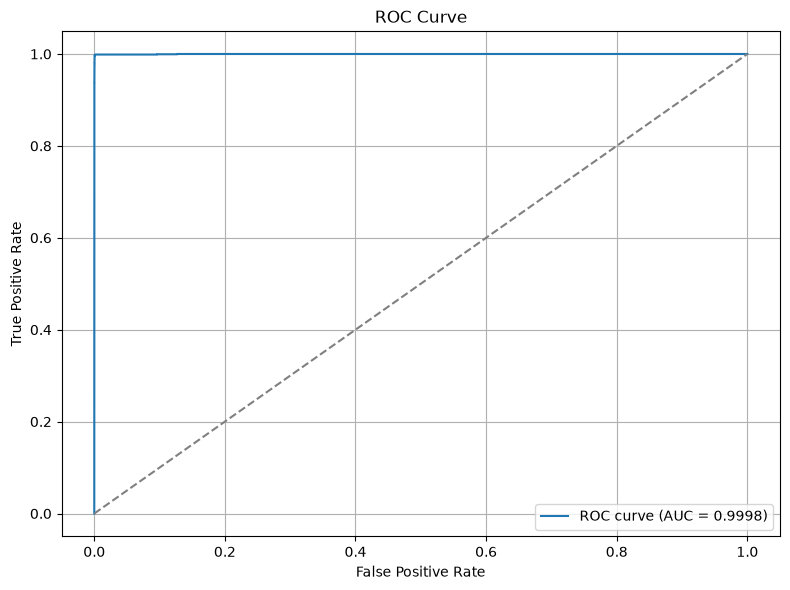

In [63]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

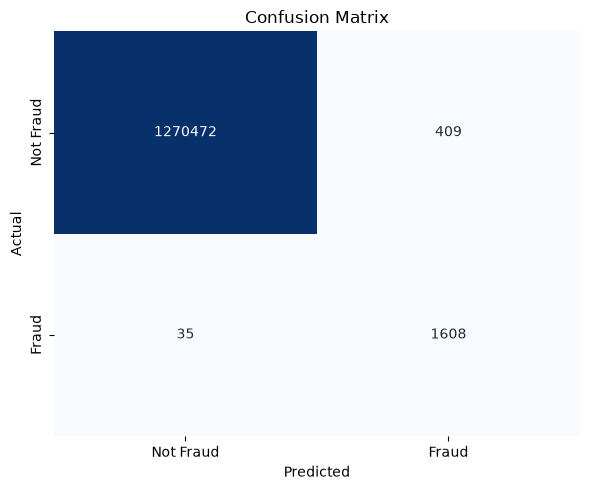

In [64]:
# Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()